# Estudo de Caso: Análise Estatística

O estudo de caso refere-se a uma base de dados para um sistema de recomendação de filmes. A base de dados a ser utilizada nesta seção será do Movielens 10M, em que 71567 usuários avaliaram 10681 filmes de diversos gêneros.

Cada usuário avaliou um mínimo de 20 filmes diferentes com notas que variam entre 1 (nota ruim) e 5 (excelente nota), totalizando 10 milhões de avaliações.
Esta base de dados está disponível no site oficial do projeto:
[MovieLens](https://grouplens.org/datasets/movielens/10M/).

---

### Objetivos:
1. Processar e unificar os dados de filmes e avaliações dos usuários.
2. Extrair métricas estatísticas de tendência central e dispersão agrupadas por gênero.
3. Visualizar graficamente o comportamento das notas por categoria em relação à média geral.
4. Executar a divisão estratificada dos dados (70% Treino e 30% Teste por usuário) para validar modelos de recomendação.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 1. Carregamento e Tratamento dos Dados

Nesta etapa, carregamos os arquivos `.dat` utilizando o delimitador `::`. Em seguida:
- Convertemos a coluna `Data` de formato Unix Timestamp para `datetime`.
- Realizamos o `merge` entre avaliações e filmes utilizando a chave `Id_Filme`.
- Extraímos o primeiro gênero listado em `Gênero_Filme` para padronizar a análise.

In [119]:
# DataFrame da tabela dos filmes
filmes = pd.read_csv('/content/movies.dat',
                     sep='::',
                     engine='python',
                     names=['Id_Filme', 'Nome', 'Gênero_Filme']
                     )

# DataFrame da tabela de avaliações
avaliacoes = pd.read_csv('/content/ratings.dat',
                     sep='::',
                     engine='python',
                     names=["Id_Usuario", "Id_Filme", "Avaliação", "Data"]
                     )

# Converte o Timestamp para uma data legível
avaliacoes["Data_Hora"] = pd.to_datetime(avaliacoes["Data"], unit="s")

In [120]:
# Visualização do resultado do DataFrame 'filmes'
filmes.head()

,Id_Filme,Nome,Gênero_Filme
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [121]:
# Visualização do resultado do DataFrame 'avaliacoes'
avaliacoes.head()

,Id_Usuario,Id_Filme,Avaliação,Data,Data_Hora
0,1,122,5.0,838985046,1996-08-02 11:24:06
1,1,185,5.0,838983525,1996-08-02 10:58:45
2,1,231,5.0,838983392,1996-08-02 10:56:32
3,1,292,5.0,838983421,1996-08-02 10:57:01
4,1,316,5.0,838983392,1996-08-02 10:56:32


In [122]:
# Junção dos dois DataFrames com base na coluna 'Id_Filme'
filmes_completo = pd.merge(avaliacoes, filmes, on="Id_Filme")

# Cópia do DataFrame filtrado apenas com as colunas necessárias e na ordem específica
filmes_final = filmes_completo[["Id_Usuario", "Id_Filme", "Avaliação", "Gênero_Filme"]].copy()

# Substitui os dados da coluna Gênero_Filme apenas pelo primeiro gênero
filmes_final["Gênero_Filme"] = filmes_final["Gênero_Filme"].str.split("|").str[0]

# Visualização do resultado da junção dos DataFrames
filmes_final.head()

,Id_Usuario,Id_Filme,Avaliação,Gênero_Filme
0,1,122,5.0,Comedy
1,1,185,5.0,Action
2,1,231,5.0,Comedy
3,1,292,5.0,Action
4,1,316,5.0,Action


## 2. Tabela de Resumo do dataset

Abaixo quantitifiquei o volume total de entidades únicas presentes no conjunto de dados, bem como a avaliação média global da plataforma.

In [123]:
# Calculo dos valores individuais
total_usuarios = filmes_final["Id_Usuario"].nunique()  # Usuários únicos
total_filmes = filmes_final["Id_Filme"].nunique()  # Filmes únicos
total_avaliacoes = len(filmes_final)  # Total de linhas (avaliações)
avaliacao_media = filmes_final["Avaliação"].mean()  # Média de todas as avaliações

# Cria o DataFrame de resumo com os resultados
avaliacoes_resumo = pd.DataFrame(
    [
        {
            "Usuários": total_usuarios,
            "Filmes": total_filmes,
            "Avaliações": total_avaliacoes,
            "Avaliação Média": round(
                avaliacao_media, 1
            ),
        }
    ]
)

# Visualização do resumo do DataFrame
avaliacoes_resumo.head()

,Usuários,Filmes,Avaliações,Avaliação Média
0,69878,10677,10000054,3.5


## 3. Análise Estatística por Gênero


Para compreender a distribuição das avaliações entre as diferentes categorias de filmes, foram calculadas as seguintes métricas estatísticas:
* **Média e Mediana:** Medidas de tendência central.
* **Mínimo, Máximo e Amplitude:** Alcance total das avaliações atribuídas.
* **Desvio Padrão:** Grau de dispersão/variabilidade das notas em relação à média.


In [124]:
# Agrupa por gênero e calcula as métricas estatísticas
df_metricas = (
    filmes_final.groupby("Gênero_Filme")["Avaliação"]
    .agg(
        Média="mean",
        Mediana="median",
        Mínimo="min",
        Máximo="max",
        Desvio_Padrão="std",
        Contagem="count",
    )
    .reset_index()
)

# Calcula a Amplitude (Máximo - Mínimo)
df_metricas["Amplitude"] = (
    df_metricas["Máximo"] - df_metricas["Mínimo"]
)

# Arredonda os valores decimais para melhor visualização
df_metricas = df_metricas.round(2)

# Ordena pela Mediana e depois pela Média (decrescente)
df_metricas = df_metricas.sort_values(
    by=["Mediana", "Média"], ascending=[False, False]
)

# Reorganiza a ordem das colunas para apresentação
colunas_ordem = [
    "Gênero_Filme",
    "Contagem",
    "Média",
    "Mediana",
    "Mínimo",
    "Máximo",
    "Amplitude",
    "Desvio_Padrão",
]
df_metricas = df_metricas[colunas_ordem]

# Visualização do resultado
print(df_metricas.to_string(index=False))

      Gênero_Filme  Contagem  Média  Mediana  Mínimo  Máximo  Amplitude  Desvio_Padrão
         Film-Noir     17497   4.15      4.0     0.5     5.0        4.5           0.83
             Crime    588028   3.87      4.0     0.5     5.0        4.5           0.94
       Documentary     89965   3.79      4.0     0.5     5.0        4.5           1.00
           Mystery     33942   3.70      4.0     0.5     5.0        4.5           0.96
             Drama   1935659   3.67      4.0     0.5     5.0        4.5           1.00
               War      2592   3.66      4.0     0.5     5.0        4.5           0.88
           Musical     18045   3.64      4.0     0.5     5.0        4.5           1.11
         Adventure    837392   3.56      4.0     0.5     5.0        4.5           1.04
         Animation    242540   3.55      4.0     0.5     5.0        4.5           1.04
          Thriller    105342   3.53      4.0     0.5     5.0        4.5           0.97
(no genres listed)         7   3.64      3.

## 4. Visualização gráfica de Avaliações por Gênero

O gráfico a seguir apresenta a média de avaliações por gênero em comparação com a média geral da plataforma.
- **Barras em azul escuro:** Gêneros com média igual ou superior à média global.
- **Barras em azul claro:** Gêneros com média abaixo da média global.
- **Linha tracejada:** Indica a média geral de todas as avaliações.

In [125]:
# Agrupa e calcula a média por gênero
filmes_generos = (
    filmes_final.groupby("Gênero_Filme")["Avaliação"].mean().reset_index()
)

# Ordena os gêneros do maior para o menor
filmes_generos = filmes_generos.sort_values(by="Avaliação", ascending=False)

# Calcula a média geral das avaliações
media_geral = filmes_final["Avaliação"].mean()

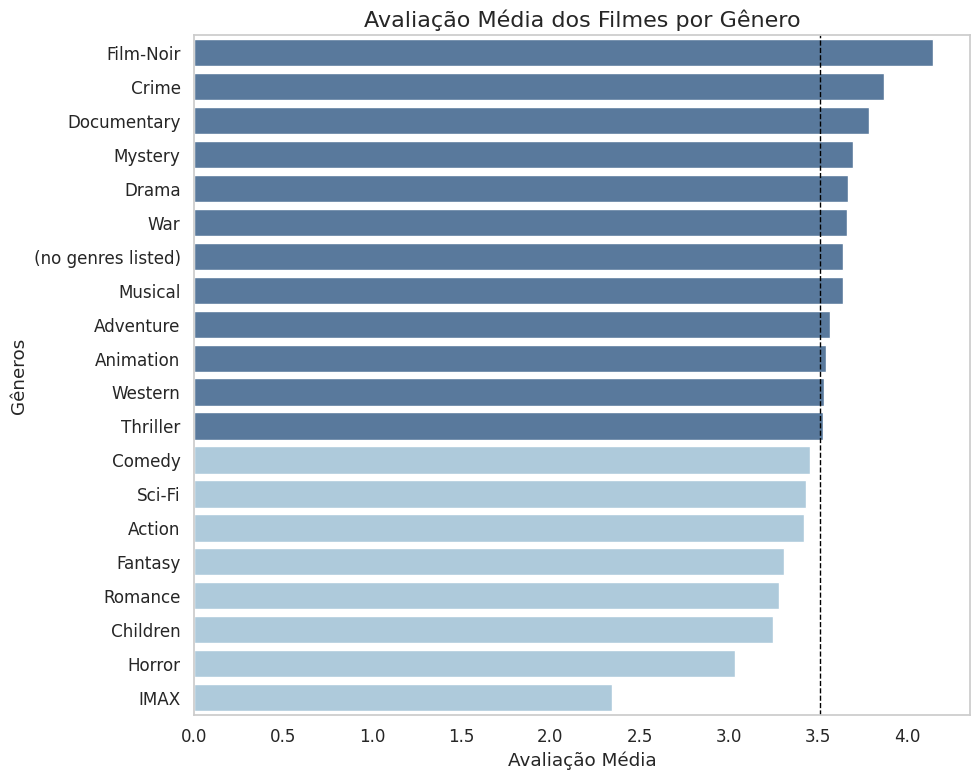

In [126]:
# Cria o gráfico
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 8))

# Cria uma paleta de cores (destacando gêneros acima e abaixo da média)
paleta = [
    "#4e79a7" if aval >= media_geral else "#a7cce2"
    for aval in filmes_generos["Avaliação"]
]

# Cria o gráfico de barras horizontais
sns.barplot(
    data=filmes_generos,
    x="Avaliação",
    y="Gênero_Filme",
    hue="Gênero_Filme",
    palette=paleta,
    legend=False,
    orient="h",
)

# Adiciona a linha de média geral
plt.axvline(x=media_geral, color="black", linestyle="--", linewidth=1)

# Adiciona os rótulos e título
plt.xlabel("Avaliação Média")
plt.ylabel("Gêneros")
plt.title("Avaliação Média dos Filmes por Gênero", fontsize=16)

# Remove a grade vertical, mantendo apenas a horizontal para foco no valor
plt.gca().xaxis.grid(False)

# Aplica um ajuste automático de margens
plt.tight_layout()

# Visuzalição do gráfico finalizado
plt.show()

## 5. Amostra de Treino e Teste

Para treinar um modelo de recomendação é crucial garantir que **70% das avaliações de cada usuário** vão para o conjunto de treino e **30% para o conjunto de teste**.

Essa amostragem estratificada baseada no `Id_Usuario` garante que o algoritmo construa um perfil individual na etapa de treino e possa ser validado corretamente na etapa de teste.

In [127]:
# Divide os dados garantindo a proporção de 70/30 por ID do usuário
df_treino, df_teste = train_test_split(
    filmes_final, test_size=0.30, random_state=42, stratify=filmes_final["Id_Usuario"]
)

# Exibe as dimensões dos dois conjuntos
print(f"Total de registros no treino: {len(df_treino)} ({len(df_treino)/len(filmes_final):.1%})")
print(f"Total de registros no teste:  {len(df_teste)} ({len(df_teste)/len(filmes_final):.1%})")

Total de registros no treino: 7000037 (70.0%)
Total de registros no teste:  3000017 (30.0%)


## 6. Validação da Amostragem

Verificamos se todos os usuários únicos estão presentes em ambas as bases de dados, garantindo que não existam usuários exclusivos de apenas um dos lados.

In [128]:
# Verifica se todos os usuários estão presentes em ambos os conjuntos
usuarios_treino = set(df_treino["Id_Usuario"])
usuarios_teste = set(df_teste["Id_Usuario"])

print(f"Usuários únicos no treino: {len(usuarios_treino)}")
print(f"Usuários únicos no teste:  {len(usuarios_teste)}")
print(
    f"Todos os usuários do teste estão no treino? {usuarios_teste.issubset(usuarios_treino)}"
)

# Exemplo de um usuário específico
user_1_treino = len(df_treino[df_treino["Id_Usuario"] == 1])
user_1_teste = len(df_teste[df_teste["Id_Usuario"] == 1])
total_user_1 = user_1_treino + user_1_teste

print(
    f"\nUsuário 1 -> Treino: {user_1_treino} ({user_1_treino/total_user_1:.0%}) | Teste: {user_1_teste} ({user_1_teste/total_user_1:.0%})"
)

Usuários únicos no treino: 69878
Usuários únicos no teste:  69878
Todos os usuários do teste estão no treino? True

Usuário 1 -> Treino: 15 (68%) | Teste: 7 (32%)
